In [2]:
import pandas as pd
import sys 
import os
dataset_df = pd.read_csv('../data/processed/dataset_metadata.csv')

In [3]:
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

if project_root not in sys.path:
    sys.path.append(project_root)

print(f"Project root added to path: {project_root}")

Project root added to path: c:\Users\collu\Desktop\alzheimer-xai-prj


In [4]:
from src.dataset import MRIDataset
from torch.utils.data import DataLoader

# 1. Create the Dataset instance using our valid patients table
alzheimer_dataset = MRIDataset(dataset_df)

# 2. Create the DataLoader
# We use a very small batch_size (e.g., 2) because 3D images consume a lot of RAM!
# shuffle=True ensures the model doesn't memorize the patient order
train_loader = DataLoader(alzheimer_dataset, batch_size=2, shuffle=True)

# 3. Test the DataLoader by pulling the first batch
try:
    # iter() turns the loader into a stream, next() grabs the first drop
    images, labels = next(iter(train_loader))
    
    print("--- PyTorch DataLoader Test ---")
    print(f"Batch Images Shape: {images.shape}")
    print(f"Batch Labels: {labels}")

except Exception as e:
    print(f"Error loading PyTorch batch: {e}")

--- PyTorch DataLoader Test ---
Batch Images Shape: torch.Size([2, 1, 176, 208, 176])
Batch Labels: tensor([1, 1])


In [5]:
import sys
import os

# 1. Path fix to find the 'src' folder
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# 2. Import our custom module
from src.data_loader import create_mri_dataset

# 3. Define the exact paths to your raw data
excel_path = r"C:\Users\collu\Desktop\alzheimer-xai-prj\data\Demographic and Clinical Data\oasis_cross-sectional.xlsx"
base_data_dir = r"C:\Users\collu\Desktop\alzheimer-xai-prj\data"

print("--- Testing the Data Loader Pipeline ---")

try:
    # 4. Run the scanner!
    live_dataset_df = create_mri_dataset(excel_path, base_data_dir)
    
    print("\n--- Results ---")
    print(f"Total patients successfully found across all discs: {len(live_dataset_df)}")
    display(live_dataset_df.head())

except Exception as e:
    print(f"An error occurred during the scan: {e}")

--- Testing the Data Loader Pipeline ---
Loading Excel file...
Excel loaded seccessfully. Found 436 entries.
Starting 3D image search...
Processed 200 patients...
Processed 250 patients...
Processed 300 patients...
Finished searching. Found 235 valid entries with matching MRI files.

--- Results ---
Total patients successfully found across all discs: 235


,ID,Path,Label
0,OAS1_0001_MR1,C:\Users\collu\Desktop\alzheimer-xai-prj\data\...,0
1,OAS1_0002_MR1,C:\Users\collu\Desktop\alzheimer-xai-prj\data\...,0
2,OAS1_0003_MR1,C:\Users\collu\Desktop\alzheimer-xai-prj\data\...,1
3,OAS1_0010_MR1,C:\Users\collu\Desktop\alzheimer-xai-prj\data\...,0
4,OAS1_0011_MR1,C:\Users\collu\Desktop\alzheimer-xai-prj\data\...,0


In [6]:
import torch
from src.model import Alzheimer3DCNN

print("--- Testing the 3D CNN Architecture ---")

try:
    # 1. Instantiate the model
    model = Alzheimer3DCNN()
    
    # 2. Create a "fake" batch of MRIs to test the math
    # Shape: [Batch Size=2, Channels=1, Depth=176, Height=208, Width=176]
    dummy_mri_batch = torch.randn(2, 1, 176, 208, 176)
    
    # 3. Pass the fake data through the model
    output = model(dummy_mri_batch)
    
    print("Success! The model processed the 3D volume.")
    print(f"Input shape: {dummy_mri_batch.shape}")
    print(f"Output shape: {output.shape} -> (2 patients, 2 scores: [Healthy, Alzheimer])")
    print(f"Raw Output Values:\n{output}")

except Exception as e:
    print(f"Architecture Error: {e}")

--- Testing the 3D CNN Architecture ---
Success! The model processed the 3D volume.
Input shape: torch.Size([2, 1, 176, 208, 176])
Output shape: torch.Size([2, 2]) -> (2 patients, 2 scores: [Healthy, Alzheimer])
Raw Output Values:
tensor([[0.0744, 0.4778],
        [0.8014, 0.0137]], grad_fn=<AddmmBackward0>)


In [7]:
from src.data_loader import create_mri_dataset
from src.dataset import MRIDataset
from src.model import Alzheimer3DCNN
from src.trainer import train_model
from torch.utils.data import DataLoader

# 1. Prepare Data
excel_path = r"C:\Users\collu\Desktop\alzheimer-xai-prj\data\Demographic and Clinical Data\oasis_cross-sectional.xlsx"
base_data_dir = r"C:\Users\collu\Desktop\alzheimer-xai-prj\data"

print("Loading dataset...")
dataset_df = create_mri_dataset(excel_path, base_data_dir)
alzheimer_dataset = MRIDataset(dataset_df)

# We use batch_size=2 because 3D images are huge. 
# If your computer crashes for "Out of Memory", lower this to 1!
train_loader = DataLoader(alzheimer_dataset, batch_size=2, shuffle=True)

# 2. Prepare Model
model = Alzheimer3DCNN()

# 3. Train! (We'll do just 2 epochs to test if the loss goes down)
try:
    trained_model = train_model(model, train_loader, num_epochs=2, learning_rate=0.0001)
    print("Training completely successfully!")
except Exception as e:
    print(f"An error occurred during training: {e}")

ImportError: cannot import name 'train_model' from 'src.trainer' (c:\Users\collu\Desktop\alzheimer-xai-prj\src\trainer.py)

In [ ]:
import torch

print("--- GPU Hardware Check ---")
print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")
    print(f"Device Count: {torch.cuda.device_count()}")
else:
    print("PyTorch still cannot see the GPU.")

--- GPU Hardware Check ---
CUDA Available: True
Device Name: NVIDIA GeForce RTX 5070 Laptop GPU
Device Count: 1


c:\Users\collu\Desktop\alzheimer-xai-prj\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- Extracting XAI Heatmap ---
Patient True Label: Alzheimer
AI Predicted Label: Alzheimer
Generating 3D Heatmap overlay...


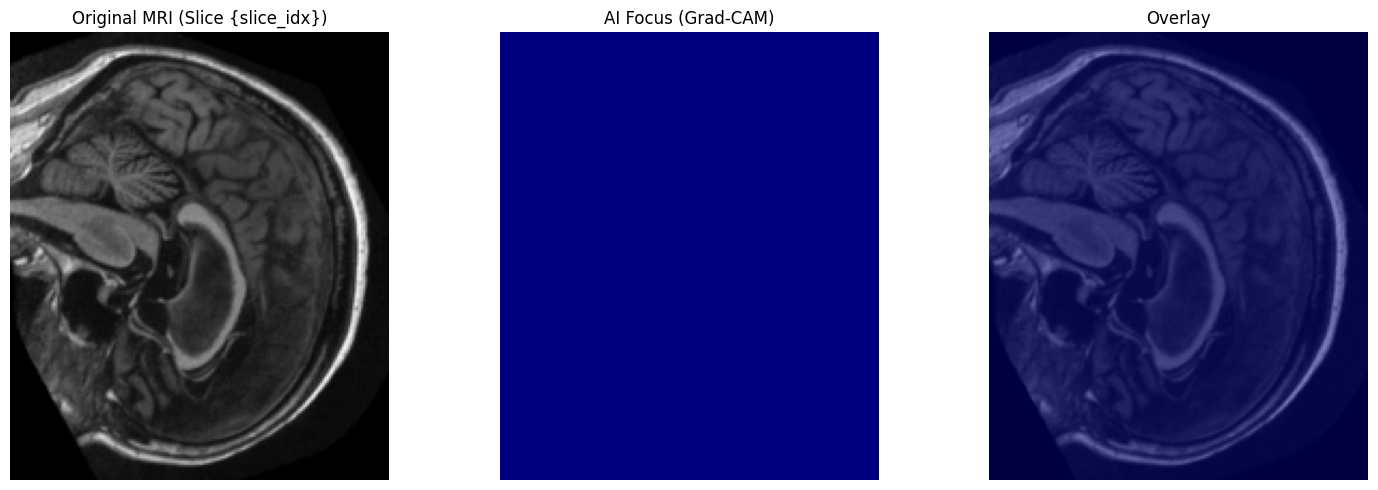

In [ ]:
from src.xai import generate_and_plot_gradcam

print("--- Extracting XAI Heatmap ---")

# 1. Get a single patient from our DataLoader
# iter() and next() grab the first batch. We take the first image [0]
images, labels = next(iter(train_loader))
single_patient_img = images[0].unsqueeze(0).to('cuda') # Move to GPU
real_label = labels[0].item()

print(f"Patient True Label: {'Alzheimer' if real_label == 1 else 'Healthy'}")

# 2. Let the model predict
trained_model.eval()
with torch.no_grad():
    prediction_scores = trained_model(single_patient_img)
    predicted_class = torch.argmax(prediction_scores, dim=1).item()

print(f"AI Predicted Label: {'Alzheimer' if predicted_class == 1 else 'Healthy'}")

# 3. Generate Explainability Map (Why did it predict what it predicted?)
# We ask the model to explain its prediction
print("Generating 3D Heatmap overlay...")
generate_and_plot_gradcam(trained_model, single_patient_img, target_class=predicted_class)

In [10]:
import os
import torch
from torch.utils.data import DataLoader, random_split
from src.model import Alzheimer3DCNN
from src.trainer import train_and_validate

print("--- Data Splitting ---")
total_patients = len(alzheimer_dataset)
train_size = int(0.8 * total_patients)
val_size = total_patients - train_size

print(f"Total valid patients: {total_patients}")
print(f"Training set size: {train_size}")
print(f"Validation set size: {val_size}")

train_dataset, val_dataset = random_split(alzheimer_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)

model = Alzheimer3DCNN()

save_path = os.path.join(project_root, 'models', 'best_alzheimer_3dcnn.pth')

try:
    trained_model = train_and_validate(
        model, 
        train_loader, 
        val_loader, 
        num_epochs=30, 
        learning_rate=0.0001, 
        save_path=save_path
        )
    
except Exception as e:
    print(f"An error occurred during training & validation: {e}")


--- Data Splitting ---
Total valid patients: 25
Training set size: 20
Validation set size: 5
Using device: cuda
--- Starting Training & Validation Loop ---
An error occurred during training & validation: cannot access local variable 'running_train_loss' where it is not associated with a value
